# Problem Definition

The objective of this project is to build a machine learning model that predicts whether a student will be placed or not. The prediction is based on various academic, technical, and extracurricular factors such as CGPA, branch, coding skills, DSA score, communication skills, machine learning knowledge, internships, projects, certifications, hackathons, open-source contributions, and extracurricular activities.

This is a supervised machine learning classification problem where the target variable is `placement_status`.


2.Data COllection...

In [1]:
import pandas as pd
df=pd.read_csv("../data/student_placement_synthetic.csv")
df.shape


(100000, 18)

In [2]:
df.head()

,branch,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,placement_status,salary_package_lpa
0,ECE,Tier-3,6.70,0,7.6,4.4,49.5,3.7,6.4,0.3,1,4,4,3,2,1,1,14.75
1,Chemical,Tier-2,5.70,0,5.4,7.9,72.0,8.3,6.3,1.9,0,4,0,0,0,0,0,NaN
2,EE,Tier-2,7.19,0,5.6,6.8,79.1,7.4,4.4,5.2,1,3,2,1,2,0,1,19.06
3,CE,Tier-2,6.48,0,5.2,3.1,48.4,5.0,1.1,6.7,1,4,3,0,0,0,0,NaN
4,CSE,Tier-2,6.71,1,5.9,4.7,61.2,4.3,2.7,2.8,1,2,0,3,0,1,1,13.42


In [3]:
df.columns

Index(['branch', 'college_tier', 'cgpa', 'backlogs', 'coding_skills',
       'dsa_score', 'aptitude_score', 'communication_skills', 'ml_knowledge',
       'system_design', 'internships', 'projects_count', 'certifications',
       'hackathons', 'open_source_contributions', 'extracurriculars',
       'placement_status', 'salary_package_lpa'],
      dtype='object')

### Observations

- The dataset contains 100000 rows and 18 columns.
- The dataset includes academic, technical, and extracurricular features.
- The target variable is placement_status.

#3.Data Understanding

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   branch                     100000 non-null  object 
 1   college_tier               100000 non-null  object 
 2   cgpa                       100000 non-null  float64
 3   backlogs                   100000 non-null  int64  
 4   coding_skills              100000 non-null  float64
 5   dsa_score                  100000 non-null  float64
 6   aptitude_score             100000 non-null  float64
 7   communication_skills       100000 non-null  float64
 8   ml_knowledge               100000 non-null  float64
 9   system_design              100000 non-null  float64
 10  internships                100000 non-null  int64  
 11  projects_count             100000 non-null  int64  
 12  certifications             100000 non-null  int64  
 13  hackathons                 100

In [5]:
df.isnull().sum()

branch                           0
college_tier                     0
cgpa                             0
backlogs                         0
coding_skills                    0
dsa_score                        0
aptitude_score                   0
communication_skills             0
ml_knowledge                     0
system_design                    0
internships                      0
projects_count                   0
certifications                   0
hackathons                       0
open_source_contributions        0
extracurriculars                 0
placement_status                 0
salary_package_lpa           31525
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df['placement_status'].value_counts()

placement_status
1    68475
0    31525
Name: count, dtype: int64

### Observations

- No duplicate records were found in the dataset.
- Missing values are present only in the `salary_package_lpa` column.
- The target variable is `placement_status`.
- The dataset is slightly imbalanced, with more placed students than non-placed students.
- Since the classes are not perfectly balanced, accuracy alone may not be sufficient for model evaluation. Metrics such as Precision, Recall, and F1-score should also be considered.

### Feature Types

Categorical Features:
- branch
- college_tier
- placement_status (target)


Numerical Features:
- cgpa
- backlogs
- coding_skills
- dsa_score
- aptitude_score
- communication_skills
- ml_knowledge
- system_design
- internships
- projects_count
- certifications
- hackathons
- open_source_contributions
- extracurriculars
- salary_package_lpa


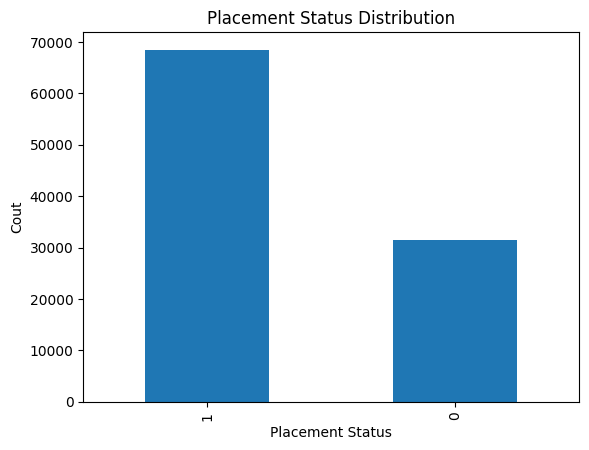

In [8]:
import matplotlib.pyplot as plt
df["placement_status"].value_counts().plot(kind="bar")
plt.title("Placement Status Distribution")
plt.xlabel("Placement Status")
plt.ylabel("Cout")
plt.show()

### Observations

- The majority class is "Placed".
- Approximately 68.5% of students are placed, while 31.5% are not placed.
- The dataset is slightly imbalanced but not severely imbalanced.
- Model evaluation should not rely only on accuracy; precision, recall, and F1-score should also be considered.

### Students with higher CGPA are more likely to get placed.

In [9]:
df.groupby('placement_status')['cgpa'].mean()

placement_status
0    7.003297
1    7.299878
Name: cgpa, dtype: float64

### Observation
Placed students have a slightly higher average CGPA compared to non-placed students.

The difference is not very large, suggesting that CGPA alone may not determine placement outcomes. Other factors such as coding skills, internships, projects, and communication skills may also play an important role.

In [10]:
df.groupby("placement_status")["coding_skills"].mean()

placement_status
0    5.801843
1    6.084142
Name: coding_skills, dtype: float64

In [11]:
df.groupby('placement_status')['internships'].mean()

placement_status
0    0.956511
1    1.158817
Name: internships, dtype: float64

Hypothesis:
Students with internship experience are more likely to get placed.

Analysis:
Calculated the average number of internships for placed and non-placed students.

Results:
Not Placed = 0.956
Placed = 1.159

Observation:
Placed students have slightly more internship experience on average.

In [12]:
df.groupby("placement_status")["projects_count"].mean()

placement_status
0    2.269247
1    2.456225
Name: projects_count, dtype: float64

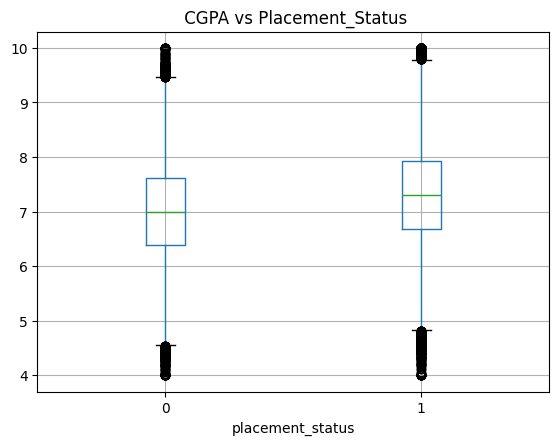

In [13]:
import matplotlib.pyplot as plt
plt.Figure(figsize=(8,5))
df.boxplot(column="cgpa",by="placement_status")
plt.title(" CGPA vs Placement_Status")
plt.suptitle("")
plt.show()

### CGPA vs Placement Status

Observations:

- Placed students have a slightly higher median CGPA compared to non-placed students.
- There is significant overlap between the two distributions.
- Some students with high CGPA are not placed, while some students with lower CGPA are placed.
- This suggests that CGPA alone is not sufficient to determine placement outcomes.
- Other factors such as coding skills, internships, projects, and communication skills may also influence placement.

In [14]:
pd.crosstab(df['college_tier'], df['placement_status'])

placement_status,0,1
college_tier,,
Tier-1,2519,12349
Tier-2,10951,28959
Tier-3,18055,27167


In [15]:
pd.crosstab(df["college_tier"],df["placement_status"],normalize='index')*100

placement_status,0,1
college_tier,,
Tier-1,16.942427,83.057573
Tier-2,27.439238,72.560762
Tier-3,39.925258,60.074742


### Hypothesis

Students from higher-tier colleges are more likely to get placed.

### Analysis

Calculated placement percentage across college tiers.

### Observation

### Observation

- Placement rates vary significantly across college tiers.
- Tier-1 colleges have the highest placement rate (83.06%).
- Tier-2 colleges have a placement rate of 72.56%.
- Tier-3 colleges have the lowest placement rate (60.07%).
- This suggests that college tier may be an important factor influencing placement outcomes.

In [16]:
df.groupby("placement_status")["dsa_score"].mean()

placement_status
0    5.273294
1    5.605411
Name: dsa_score, dtype: float64

In [17]:
pd.crosstab(
    df['dsa_score'],
    df['placement_status'],
    normalize='index'
) * 100

placement_status,0,1
dsa_score,,
1.0,45.689655,54.310345
1.1,38.518519,61.481481
1.2,46.376812,53.623188
1.3,46.428571,53.571429
1.4,41.212121,58.787879
...,...,...
9.6,23.926380,76.073620
9.7,24.516129,75.483871
9.8,15.625000,84.375000


In [18]:
df.groupby('placement_status')['hackathons'].mean()

placement_status
0    0.702427
1    0.765827
Name: hackathons, dtype: float64

In [19]:
df.groupby('placement_status')['communication_skills'].mean()

placement_status
0    5.878052
1    6.042436
Name: communication_skills, dtype: float64

In [20]:
pd.crosstab(
    df['branch'],
    df['placement_status'],
    normalize='index'
) * 100

placement_status,0,1
branch,,
CE,35.335196,64.664804
CSE,28.651282,71.348718
Chemical,35.446774,64.553226
ECE,30.423723,69.576277
EE,33.650347,66.349653
IT,29.106754,70.893246
ME,33.594270,66.405730


CSE and IT students show the highest placement rates (71.35% and 70.89% respectively), while Civil Engineering and Chemical Engineering students have comparatively lower placement rates. Although branch appears to influence placement outcomes, the variation across branches is moderate and considerably smaller than the variation observed across college tiers. This suggests that branch may contribute to placement prediction but is unlikely to be the dominant factor.

## Data Preprocessing

### Preprocessing Strategy

1. Remove salary_package_lpa to avoid data leakage.
2. Separate features (X) and target (y).
3. Split data into train and test sets (80:20) using stratified sampling.
4. Apply Ordinal Encoding to college_tier.
5. Apply One-Hot Encoding to branch.
6. Scale numerical features for Logistic Regression.

In [21]:
# Remove salary column
df=df.drop("salary_package_lpa",axis=1)

# Create X 
X=df.drop("placement_status",axis=1)

# Create y
y=df["placement_status"]

# Check shapes
print("X shape:",X.shape)
print("y shape:",y.shape)

print("\nFeatures:")
print(X.columns.tolist())

X shape: (100000, 16)
y shape: (100000,)

Features:
['branch', 'college_tier', 'cgpa', 'backlogs', 'coding_skills', 'dsa_score', 'aptitude_score', 'communication_skills', 'ml_knowledge', 'system_design', 'internships', 'projects_count', 'certifications', 'hackathons', 'open_source_contributions', 'extracurriculars']


### Observation

The salary_package_lpa column was removed because it contains post-placement information and may cause data leakage. The dataset was then divided into features (X) and target variable (y), where placement_status is the target for prediction.

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (80000, 16)
X_test : (20000, 16)
y_train: (80000,)
y_test : (20000,)


In [23]:
print(X_train['college_tier'].unique())
print(X_train['branch'].unique())

['Tier-3' 'Tier-2' 'Tier-1']
['ME' 'IT' 'ECE' 'EE' 'CE' 'CSE' 'Chemical']


In [24]:
tier_mapping = {
    'Tier-3': 1,
    'Tier-2': 2,
    'Tier-1': 3
}

X_train['college_tier'] = X_train['college_tier'].map(tier_mapping)
X_test['college_tier'] = X_test['college_tier'].map(tier_mapping)

print(X_train['college_tier'].head())

18271    1
2475     2
11593    1
84051    1
61631    1
Name: college_tier, dtype: int64


The college_tier feature has a natural ranking (Tier-1 > Tier-2 > Tier-3). Therefore, Ordinal Encoding was applied to preserve this order.

In [25]:
X_train = pd.get_dummies(
    X_train,
    columns=['branch'],
    drop_first=True
)

X_test = pd.get_dummies(
    X_test,
    columns=['branch'],
    drop_first=True
)

In [26]:
print(X_train.shape)
print(X_test.shape)

print(X_train.head())

(80000, 21)
(20000, 21)
       college_tier  cgpa  backlogs  coding_skills  dsa_score  aptitude_score  \
18271             1  7.77         3            7.5        5.1            54.9   
2475              2  6.97         0            7.2        3.8            52.2   
11593             1  7.44         0            6.2        4.0            66.2   
84051             1  7.15         0            4.9        6.2            50.2   
61631             1  7.59         0            7.7        7.5            66.6   

       communication_skills  ml_knowledge  system_design  internships  ...  \
18271                   4.7           2.9            1.9            0  ...   
2475                    6.6           5.7            2.0            1  ...   
11593                   6.3           2.3            3.4            1  ...   
84051                   6.1           7.4            6.9            1  ...   
61631                   8.2           7.8            5.2            1  ...   

       certification

In [27]:
num_cols = [
    'college_tier',
    'cgpa',
    'backlogs',
    'coding_skills',
    'dsa_score',
    'aptitude_score',
    'communication_skills',
    'ml_knowledge',
    'system_design',
    'internships',
    'projects_count',
    'certifications',
    'hackathons',
    'open_source_contributions',
    'extracurriculars'
]

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [29]:
X_train[num_cols].describe().round(2)

,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars
count,80000.00,80000.00,80000.00,80000.00,80000.00,80000.00,80000.00,80000.00,80000.00,80000.00,80000.00,80000.00,80000.00,80000.00,80000.00
mean,-0.00,-0.00,-0.00,0.00,-0.00,-0.00,0.00,-0.00,0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-0.98,-3.46,-0.63,-3.33,-2.53,-3.76,-3.33,-2.29,-2.26,-1.16,-1.93,-1.35,-0.85,-0.67,-1.19
25%,-0.98,-0.68,-0.63,-0.66,-0.67,-0.68,-0.66,-0.66,-0.68,-1.16,-1.12,-0.45,-0.85,-0.67,-1.19
50%,0.43,0.00,-0.63,0.00,-0.00,0.00,0.00,-0.00,-0.01,-0.10,-0.32,-0.45,0.29,-0.67,-0.15
75%,0.43,0.67,0.53,0.67,0.67,0.68,0.67,0.66,0.67,0.97,0.49,0.45,0.29,0.82,0.88
max,1.83,3.01,2.86,2.67,2.52,2.93,2.68,2.79,3.37,2.03,2.10,2.25,2.55,2.31,1.92


In [30]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [31]:
y_pred_lr = lr_model.predict(X_test)

In [32]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))

Accuracy : 0.69945
Precision: 0.7166948674562887
Recall   : 0.9278568820737495
F1 Score : 0.8087191726332538


In [33]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.56      0.20      0.30      6305
           1       0.72      0.93      0.81     13695

    accuracy                           0.70     20000
   macro avg       0.64      0.57      0.55     20000
weighted avg       0.67      0.70      0.65     20000



In [34]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)

print(cm)

[[ 1282  5023]
 [  988 12707]]


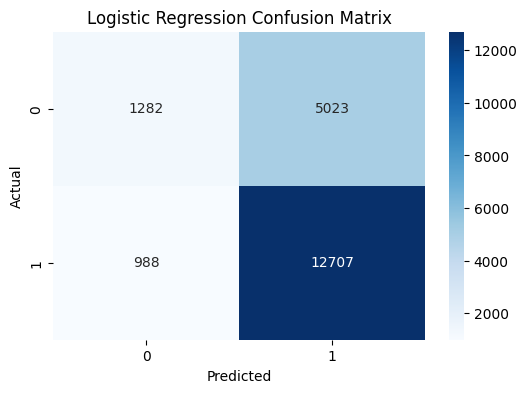

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [36]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

In [37]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.37      0.38      0.38      6305
           1       0.71      0.69      0.70     13695

    accuracy                           0.60     20000
   macro avg       0.54      0.54      0.54     20000
weighted avg       0.60      0.60      0.60     20000



In [38]:
print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))

Accuracy : 0.5968
Precision: 0.7102845619538427
Recall   : 0.6944140197152245
F1 Score : 0.7022596366858662


In [39]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.37      0.38      0.38      6305
           1       0.71      0.69      0.70     13695

    accuracy                           0.60     20000
   macro avg       0.54      0.54      0.54     20000
weighted avg       0.60      0.60      0.60     20000



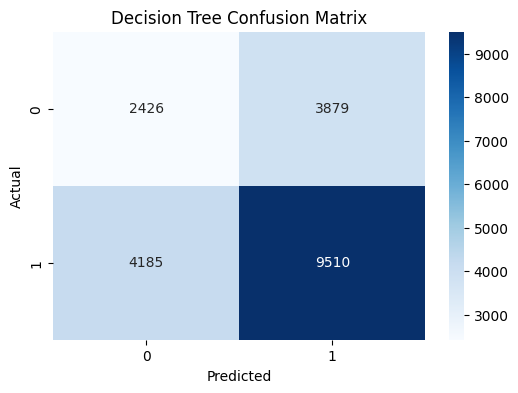

In [40]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")

plt.show()

In [41]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': dt_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
1,cgpa,0.117007
5,aptitude_score,0.115197
8,system_design,0.098946
7,ml_knowledge,0.098920
6,communication_skills,0.097246
4,dsa_score,0.096547
3,coding_skills,0.092704
10,projects_count,0.034218
11,certifications,0.032555
0,college_tier,0.032259


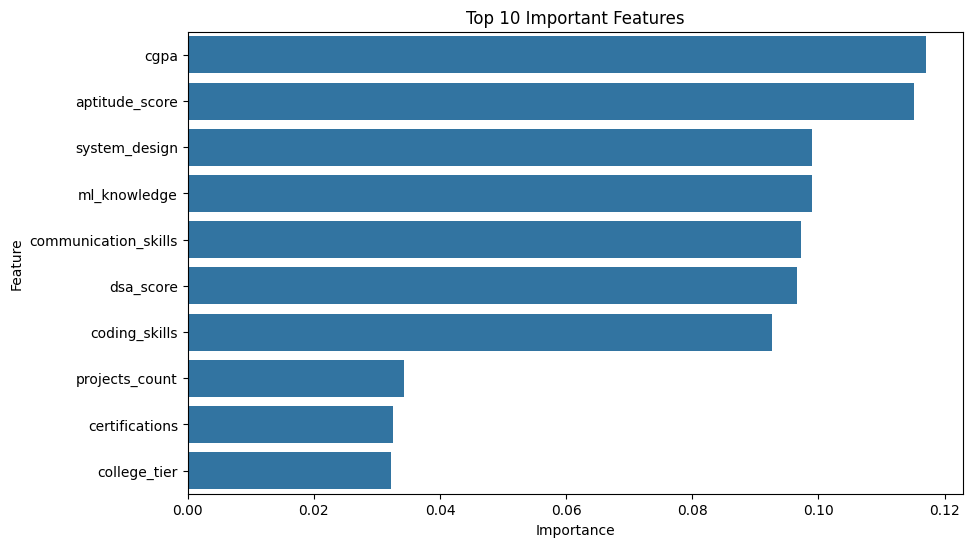

In [42]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title('Top 10 Important Features')
plt.show()

### Observation

The Decision Tree model achieved lower performance than Logistic Regression.

This suggests that the model may be overfitting the training data and failing to generalize effectively to unseen samples.

Feature importance analysis indicated that CGPA, Aptitude Score, DSA Score, Coding Skills, and Communication Skills were among the most influential predictors of placement outcomes.

In [43]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [44]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.54      0.18      0.27      6305
           1       0.71      0.93      0.81     13695

    accuracy                           0.69     20000
   macro avg       0.62      0.55      0.54     20000
weighted avg       0.66      0.69      0.64     20000



In [45]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

Accuracy : 0.69255
Precision: 0.7113251932340092
Recall   : 0.9273457466228551
F1 Score : 0.8050968334970997


In [46]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.54      0.18      0.27      6305
           1       0.71      0.93      0.81     13695

    accuracy                           0.69     20000
   macro avg       0.62      0.55      0.54     20000
weighted avg       0.66      0.69      0.64     20000



## Model Comparison

Three machine learning models were evaluated:

| Model | Accuracy | Precision|Recall | F1 Score |
|---------|---------|---------|---------|---------|
| Logistic Regression | 69.95% | 71.67% | 92.79% | 80.87% |
| Decision Tree | 59.68% | 71.03% | 69.44% | 70.23% |
| Random Forest | 69.26% | 71.13% | 92.73% | 80.51% |

Among the evaluated models, Logistic Regression achieved the best overall performance and was selected as the final model for deployment.

In [47]:
train_pred = lr_model.predict(X_train)

print("Train Accuracy:",
      accuracy_score(y_train, train_pred))

print("Test Accuracy:",
      accuracy_score(y_test, y_pred_lr))

Train Accuracy: 0.70055
Test Accuracy: 0.69945


In [48]:
train_pred_rf = rf_model.predict(X_train)

print("Train Accuracy:",
      accuracy_score(y_train, train_pred_rf))

print("Test Accuracy:",
      accuracy_score(y_test, y_pred_rf))

Train Accuracy: 1.0
Test Accuracy: 0.69255


In [49]:
train_pred_lr = lr_model.predict(X_train)

print("Train Accuracy:",
      accuracy_score(y_train, train_pred_lr))

print("Test Accuracy:",
      accuracy_score(y_test, y_pred_lr))

Train Accuracy: 0.70055
Test Accuracy: 0.69945


## Final Model Selection

Although Random Forest achieved perfect performance on the training data, its testing accuracy remained significantly lower, indicating overfitting.

Logistic Regression achieved nearly identical performance on both training and testing datasets, demonstrating strong generalization capability.

Therefore, Logistic Regression was selected as the final model for deployment.

In [50]:
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_model.coef_[0]
})

coef_df = coef_df.sort_values(
    by='Coefficient',
    ascending=False
)

coef_df.head(15)

,Feature,Coefficient
0,college_tier,0.375819
15,branch_CSE,0.326150
19,branch_IT,0.297978
1,cgpa,0.270777
9,internships,0.237604
17,branch_ECE,0.225217
4,dsa_score,0.211679
3,coding_skills,0.207375
10,projects_count,0.169018
11,certifications,0.127275


In [51]:
coef_df.sort_values(
    by='Coefficient',
    ascending=True
).head(15)

,Feature,Coefficient
2,backlogs,-0.127066
16,branch_Chemical,-0.031352
14,extracurriculars,-0.006966
8,system_design,-0.005391
7,ml_knowledge,0.011363
13,open_source_contributions,0.046095
20,branch_ME,0.066441
18,branch_EE,0.077323
12,hackathons,0.082315
5,aptitude_score,0.109790


### Feature Importance Analysis

The Logistic Regression coefficients indicate that technical skills and practical experience have the strongest positive influence on placement outcomes.

Key positive predictors include:

- DSA Score
- Coding Skills
- Projects Count
- Certifications
- Communication Skills

The strongest negative predictor was the number of backlogs, suggesting that academic arrears reduce the likelihood of placement.

These findings align with industry expectations, where technical proficiency, project experience, and communication skills are important factors during campus recruitment.

In [52]:
import joblib

joblib.dump(lr_model, 'placement_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [53]:
import os

print(os.listdir())

['placement_model.pkl', 'placement_prediction.ipynb', 'scaler.pkl']


In [54]:
sample_prediction = lr_model.predict(X_test.iloc[[0]])

print("Prediction:", sample_prediction)

Prediction: [1]


## Future Improvements

The following improvements can be explored in future versions of this project:

- Collect real-world placement data instead of synthetic data.
- Perform hyperparameter tuning using GridSearchCV.
- Experiment with advanced ensemble models such as XGBoost and LightGBM.
- Deploy the model using Streamlit for interactive predictions.
- Incorporate additional student profile features such as interview performance and resume quality.

## Final Conclusion

The objective of this project was to predict student placement outcomes using machine learning techniques.

After data preprocessing, feature engineering, and model evaluation, three models were compared:

- Logistic Regression
- Decision Tree
- Random Forest

Among these models, Logistic Regression demonstrated the best balance between performance and generalization.

Key findings from the project include:

- DSA Score and Coding Skills were strong positive predictors of placement.
- Projects, Certifications, and Communication Skills also contributed positively.
- Backlogs negatively impacted placement probability.
- Random Forest showed signs of overfitting, whereas Logistic Regression generalized well on unseen data.

The final Logistic Regression model was saved and can be used for deployment in future applications.